# Preamble

In [1]:
from matplotlib import pyplot as plt # plotting
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process import kernels
#import pytorch as torch
import numpy as np
import time

# Function definitions

In [2]:
def RBF (x1, x2, width):
    return np.exp(- ((x1 - x2)**2)/width)

def slice(x1,kernel):
    return lambda x2,width : kernel(x1,x2,width)

def Kcomp(x1,x2,width,kernel,project=False,included=0):
    if project==True:
        xm = x1[included]
        Kmm = kernel(xm,xm.T,width)
        Km1 = kernel(xm,x1.T,width)
        K1m = Km1.T
        Km2 = kernel(xm,x2.T,width)
        K2m = Km2.T
        K22 = kernel(x2,x2.T,width)
        return Kmm,Km1,K1m,Km2,K2m,K22
    else:
        K11 = kernel(x1,x1.T,width)
        K12 = kernel(x1,x2.T,width)
        K21 = K12.T
        K22 = kernel(x2,x2.T,width)
        return K11,K12,K21,K22

def post(x1,x2,y,width,kernel,noise=0,project=False,included=0):
    N = len(x1)
    if project==True:
        Kmm,Km1,K1m,Km2,K2m,K22 = Kcomp(x1,x2,width,kernel,project,included)
        f = K2m@np.linalg.inv(noise**2 *Kmm + Km1@K1m)@Km1@y
        Kmm_inv = np.linalg.inv(Kmm)
        err_inv = np.linalg.inv(Kmm + Km1@K1m/(noise**2))
        cov = K22 - K2m@(Kmm_inv - err_inv)@Km2
    else:
        K11,K12,K21,K22 = Kcomp(x1,x2,width,kernel,project)
        K11_inv = np.linalg.inv(K11 + np.eye(N)*noise**2)
        f = K21@K11_inv@y
        cov = K22 - K21@K11_inv@K12
    return f[:,0],cov

def MSLL(y1,y2,noise,var,project=False,included=0):
    star = noise**2 + var
    log_loss = ( 0.5 * np.log(2*np.pi*star)) + ( (y1 - y2)**2 / (2*star))

    if project==False:
        simple_mean, simple_var =  np.mean(y1), np.std(y1)**2
    else:
        simple_mean, simple_var =  np.mean(y1[included]), np.std(y1[included])**2
    simple_star = noise**2 + simple_var
    simple_loss = ( 0.5 * np.log(2*np.pi*simple_var)) + ( (y1 - simple_mean)**2 / (2*simple_var))
    return np.mean(log_loss - simple_loss)

def htune(x1,x2,y1,kernel):
    #width and noise are hyperparameters to be tuned
    
    #f,cov = post(x1[:,None],x2[:,None],y1[:,None],width,kernel,noise)
    #var = np.diag(cov)[:,None]
    
    return

def sd_algo(x1,x2,y,M_sd,width,kernel,noise=0):
    N = y.shape[0]
    included = np.array(np.zeros(N),dtype="bool")
    i = np.random.randint(low=0,high=N-1)
    included[i] = True

    for m in range(M_sd):
        f,cov = post(x1[included,None],x2[:,None],y1[included,None],width,kernel,noise_sd)
        var = np.diag(cov)
        i_new = np.argmax(var)
        included[i_new] = True
    return f,var,included,cov

# Data + Hyperparameters

In [3]:
N = 100
x1 = np.array(range(N))/2
x2 = np.array(range(N))/2
y1 = np.random.rand(N)*0.01 + np.sin(x1) + 0.1*x1


kernel = RBF

# Processes

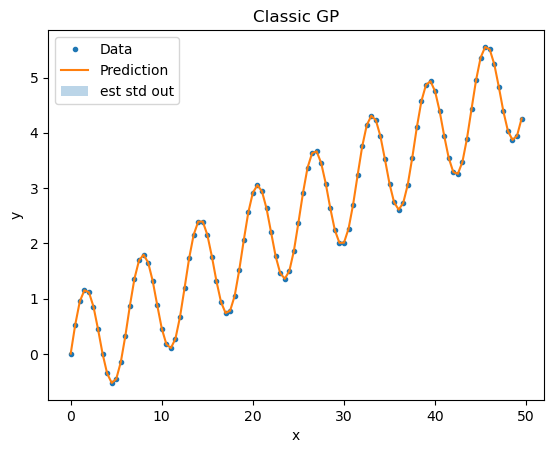

In [4]:
# CLASSICAL GP

width = 0.1
noise = 0.01

classic_start = time.time()
f,cov = post(x1[:,None],x2[:,None],y1[:,None],width,kernel,noise)
var = np.diag(cov)[:,None]
classic_end = time.time()
classic_run = classic_end - classic_start
classic_msll = MSLL(y1,f,noise,var)

var = var[:,0]

plt.title('Classic GP')

plt.plot(x1,y1,label="Data",marker=".",linestyle="none")
plt.plot(x2,f,label="Prediction")
plt.fill_between(x2,f+var,f-var,alpha=0.3,label='est std out')

plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

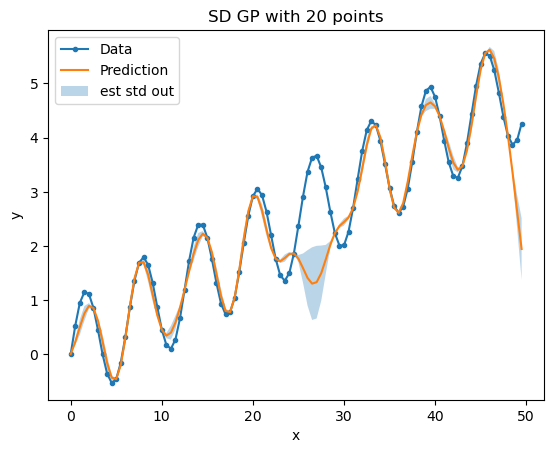

In [5]:
# SD GP

width_sd = 5
noise_sd = 0.01
M_sd = 20

sd_start = time.time()

f_sd,var_sd,include_sd,cov_sd = sd_algo(x1,x2,y1,M_sd,width_sd,kernel,noise_sd)

sd_end = time.time()
sd_run = sd_end - sd_start

sd_msll = MSLL(y1,f_sd,noise_sd,var_sd)

plt.title('SD GP with ' + str(M_sd) + " points")

plt.plot(x1,y1,label="Data",marker=".")
plt.plot(x2,f_sd,label="Prediction")
plt.fill_between(x2,f_sd+var_sd,f_sd-var_sd,alpha=0.3,label='est std out')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

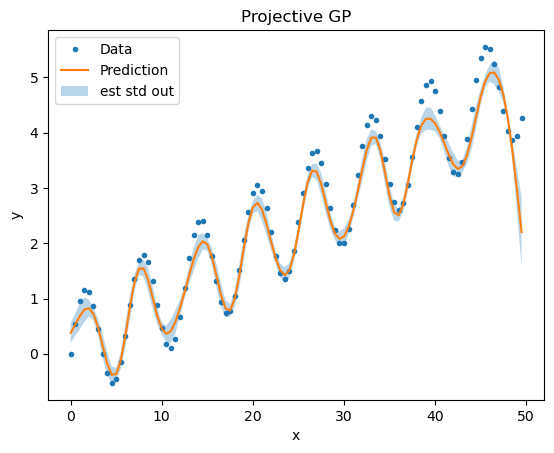

In [14]:
# PP GP

width_pp = 5
noise_pp = 0.75

pp_start = time.time()
f_pp,cov_pp = post(x1[:,None],x2[:,None],y1[:,None],width_pp,kernel,noise_pp,project=True,included=include_sd)
var_pp = np.diag(cov_pp)[:,None]
pp_end = time.time()
pp_run = pp_end - pp_start + sd_run
pp_msll = MSLL(y1,f_pp,noise_pp,var_pp,project=True,included=include_sd)

var_pp = var_pp[:,0]

plt.title('Projective GP')

plt.plot(x1,y1,label="Data",marker=".",linestyle="none")
plt.plot(x2,f_pp,label="Prediction")
plt.fill_between(x2,f_pp+var_pp,f_pp-var_pp,alpha=0.3,label='est std out')

plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

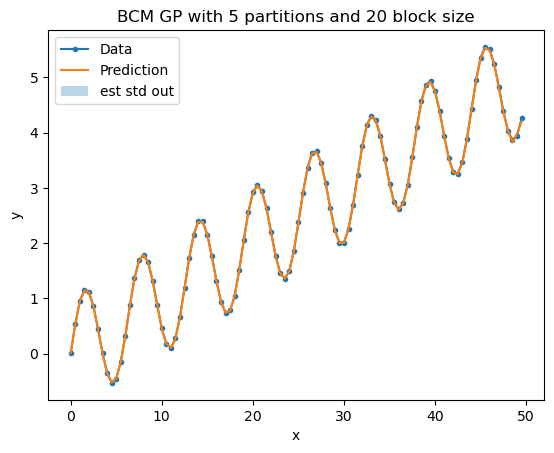

In [7]:
# BCM GP

width_bcm = 1
noise_bcm = 0.1

p_bcm = 5 #no of partitions

M_bcm = 20 #partition block size
t_bcm = 100 #test block size
s_bcm = M_bcm #SD approximation block size

#x2 = np.linspace(10,50,t_bcm)

bcm_start = time.time()

f_bcm = np.array(np.zeros([t_bcm, p_bcm]))
f_bcm_run = np.array(np.zeros(t_bcm))
var_bcm = f_bcm
include_bcm = np.array(np.zeros([N, p_bcm]),dtype="bool")
inv_cov_bcm = np.array(np.zeros([t_bcm, t_bcm, p_bcm]))
inv_cov_bcm_run = np.array(np.zeros([t_bcm, t_bcm]))

K22 = RBF(x2[:,None],x2[None,:],width_bcm)

for p in range(p_bcm):
    x11 = x1[p*M_bcm:((p+1)*M_bcm),None]
    y11 = y1[p*M_bcm:((p+1)*M_bcm),None]
    f_bcm[:,p],inv_cov_bcm[:,:,p] = post(x11,x2[:,None],y11,width_bcm,kernel,noise_bcm)
    inv_cov_bcm[:,:,p] = np.linalg.inv(inv_cov_bcm[:,:,p])
    inv_cov_bcm_run = inv_cov_bcm_run + inv_cov_bcm[:,:,p]
    f_bcm_run = f_bcm_run + inv_cov_bcm[:,:,p]@f_bcm[:,p]

cov_bcm = np.linalg.inv( -(p_bcm-1)*np.linalg.inv(K22)  +   inv_cov_bcm_run)
var_bcm = np.diag(cov_bcm)
f_bcm = cov_bcm@f_bcm_run

bcm_end = time.time()
bcm_run = bcm_end - bcm_start

bcm_msll = MSLL(y1,f_bcm,noise_bcm,var_bcm)

plt.title('BCM GP with ' + str(p_bcm) + " partitions and " + str(s_bcm) + " block size")

plt.plot(x1,y1,label="Data",marker=".")
plt.plot(x2,f_bcm,label="Prediction")
plt.fill_between(x2,f_bcm+var_bcm,f_bcm-var_bcm,alpha=0.3,label='est std out')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [13]:
print("Classic algorithm runtime = ", classic_run)
print("Classic algorithm utility = ", -classic_msll, "\n")

print("SD algorithm runtime = ", sd_run)
print("SD algorithm utility = ", -sd_msll, "\n")

print("PP algorithm runtime = ", pp_run)
print("PP algorithm utility = ", -pp_msll, "\n")

print("BCM algorithm runtime = ", bcm_run)
print("BCM algorithm utility = ", -bcm_msll)

Classic algorithm runtime =  0.00455021858215332
Classic algorithm utility =  5.196035104427037 

SD algorithm runtime =  0.0054509639739990234
SD algorithm utility =  2.17301404469359 

PP algorithm runtime =  0.006139278411865234
PP algorithm utility =  1.3290440392964589 

BCM algorithm runtime =  0.005667686462402344
BCM algorithm utility =  2.952189708378711
